## Day 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# df = pd.read_hdf("e215/data/data-e215.h5", key="short")
# once you finished the analysis:
df = pd.read_hdf("e215/data/data-e215.h5", key="full")

In [2]:
pip install tables

  Using cached tables-3.11.0-cp311-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached numexpr-2.14.1-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached blosc2-4.0.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached ndindex-1.10.1-cp313-cp313-win_amd64.whl.metadata (3.7 kB)
  Using cached msgpack-1.1.2-cp313-cp313-win_amd64.whl.metadata (8.4 kB)
Using cached tables-3.11.0-cp311-abi3-win_amd64.whl (6.5 MB)
Using cached blosc2-4.0.0-cp313-cp313-win_amd64.whl (2.7 MB)
Using cached numexpr-2.14.1-cp313-cp313-win_amd64.whl (160 kB)
Using cached msgpack-1.1.2-cp313-cp313-win_amd64.whl (72 kB)
Using cached ndindex-1.10.1-cp313-cp313-win_amd64.whl (157 kB)
Using cached py_cpuinfo-9.0.0-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/6 [py-cpuinfo]
   ------ --------------------------------- 1/6 [numexpr]
   ------ --------------------------------- 1/6 [numexpr]
   ------ -------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#get the columns 10 to 30
df.iloc[:, 10:30]

,Lt_z0,Lt_d0,Lt_t0,Lt_q,Lt_nnear,Lt_typ,k_p,k_z0,k_q,pi_p,pi_z0,pi_q,pis_p,pis_z0,pis_q,deltat,nlep,Ls_px,Ls_py,Ls_pz
0,0.027143,-0.008795,3.177173,-1.0,9.0,11.0,0.664802,-0.001723,1.0,1.164266,-0.001938,-1.0,0.093933,-0.270525,-1.0,2.769498,2.0,0.092589,0.447103,0.439380
1,-0.002207,0.000054,-0.258313,1.0,7.0,13.0,1.222637,-0.009492,-1.0,1.322784,-0.000651,1.0,0.094300,0.055811,1.0,0.908162,2.0,0.009622,0.487199,0.268330
2,0.028855,-0.002092,3.377572,-1.0,13.0,13.0,1.021795,0.045317,1.0,1.112935,0.033837,1.0,0.077186,1.560115,1.0,2.190004,2.0,-0.473627,-0.295163,0.420413
3,0.007637,-0.006447,0.893887,-1.0,7.0,11.0,1.114051,0.007217,-1.0,0.896897,0.019206,-1.0,0.143435,0.566467,1.0,0.001548,2.0,0.461995,-0.754836,0.705734
4,0.041895,0.000652,4.903854,1.0,7.0,11.0,1.560955,0.010145,-1.0,0.726270,0.057377,1.0,0.168048,0.492100,1.0,3.898858,2.0,0.523217,0.163885,-0.010918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.039880,0.008018,4.668045,1.0,6.0,13.0,0.774361,0.060667,1.0,1.080947,0.070807,-1.0,0.090272,0.372593,-1.0,1.363782,2.0,-0.811029,0.795152,-0.605642
19996,-0.009937,0.000325,-1.163138,-1.0,6.0,13.0,0.810244,-0.022742,-1.0,1.135165,-0.005545,1.0,0.078682,0.295517,1.0,1.626253,2.0,0.511702,0.129662,-0.106902
19997,-0.004010,-0.000069,-0.469388,-1.0,6.0,13.0,1.177823,-0.026249,-1.0,0.981370,-0.001885,-1.0,0.102374,1.209835,-1.0,3.339927,2.0,0.274994,0.391529,0.879120
19998,-0.023956,0.063728,-2.804118,-1.0,9.0,13.0,0.910840,0.030816,1.0,0.933672,0.005538,-1.0,0.078383,-0.303867,1.0,4.828485,3.0,0.360521,0.254632,-0.376470


In [45]:
#filter events where k_q and pi_q are opposite in sign
df[(df.k_q * df.pi_q) < 0]

,Ls_p,Ls_pst,Ls_z0,Ls_d0,Ls_t0,Ls_q,Ls_typ,Ls_nnear,Lt_p,Lt_pst,...,pi_px,pi_py,pi_pz,pi_E,pis_px,pis_py,pis_pz,pis_E,Ls_theta,Lt_theta
0,0.633663,0.532656,0.003483,0.012356,0.407675,-1.0,13.0,9.0,0.892097,0.841470,...,0.524726,-0.986259,-0.327827,1.172602,0.023708,-0.046825,-0.077902,0.168235,46.100348,70.179524
1,0.556289,0.502083,0.005552,0.100182,0.649849,-1.0,11.0,7.0,1.926301,1.643543,...,-0.666673,0.889890,0.716520,1.330127,-0.054169,0.014243,0.075865,0.168441,61.160464,49.048886
4,0.548392,0.574020,0.008586,0.028082,1.004996,1.0,13.0,6.0,0.572298,0.629443,...,0.616196,0.085263,0.374833,0.739559,-0.042043,0.127945,0.100510,0.218449,91.140760,102.260609
5,0.747690,0.643597,0.028761,-0.003624,3.366585,-1.0,13.0,8.0,0.602998,0.560125,...,-0.535197,-0.773949,-0.379105,1.024028,-0.065967,-0.017532,-0.080234,0.174861,51.298525,67.070491
6,0.834724,0.822024,-0.000611,0.028179,-0.071471,-1.0,11.0,6.0,0.821975,0.734261,...,-0.427801,-0.754690,0.776211,1.172414,-0.097543,-0.010655,0.072374,0.185327,78.882797,59.155155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2463983,0.632063,0.596648,0.064432,0.000433,7.541904,1.0,13.0,9.0,1.197080,1.082101,...,0.043645,-0.748696,0.373498,0.849371,-0.073312,-0.024772,0.039269,0.164348,70.390154,61.480712
2463984,1.349476,1.166507,0.017347,0.003078,2.030484,-1.0,13.0,7.0,1.837312,2.152491,...,-0.259263,-0.532032,0.061787,0.611206,-0.072649,0.074382,0.014443,0.174639,52.018325,117.627196
2463985,0.647529,0.631448,-0.004144,-0.002025,-0.485082,1.0,13.0,11.0,0.435964,0.554712,...,0.140624,-0.649893,0.857512,1.094049,-0.028470,-0.015079,0.083341,0.165721,76.858165,142.603258
2463986,0.877105,0.828829,0.022253,0.010665,2.604774,-1.0,11.0,8.0,0.802539,0.699711,...,-0.100354,0.613729,-0.484337,0.800497,-0.125912,0.154619,0.035888,0.246026,70.545800,54.041741


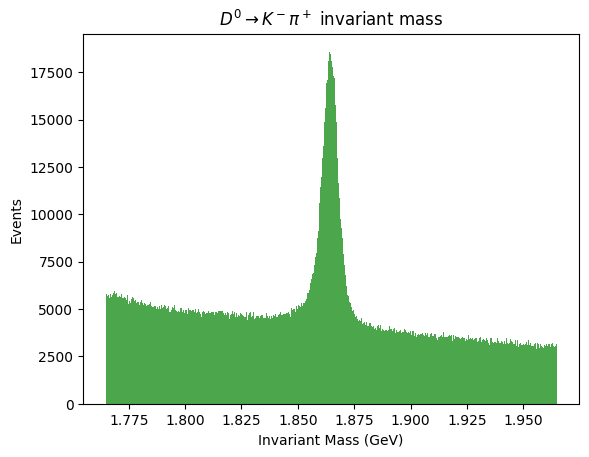

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ----------------------------
# Invariant mass
# ----------------------------
mass_squared = (
    (df["k_E"] + df["pi_E"])**2
    - (df["k_px"] + df["pi_px"])**2
    - (df["k_py"] + df["pi_py"])**2
    - (df["k_pz"] + df["pi_pz"])**2
)

df["invariant_mass"] = np.sqrt(np.clip(mass_squared, 0, None))

# ----------------------------
# Plot full histogram (GREEN)
# ----------------------------
plt.figure()
counts, bins, _ = plt.hist(
    df["invariant_mass"],
    bins=500,
    color="green",
    alpha=0.7
)

plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Events")
plt.title(r"$D^0 \rightarrow K^- \pi^+$ invariant mass")
plt.show()



In [3]:
# ----------------------------
# Sideband selection
# ----------------------------
filtered_df = df[
    (df["invariant_mass"] < 1.850) |
    (df["invariant_mass"] > 1.875)
]

# ----------------------------
# Histogram for fit
# ----------------------------
y, bin_edges = np.histogram(filtered_df["invariant_mass"], bins=500)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Remove zero bins (important for chi2)
mask = y > 0
x_fit = bin_centers[mask]
y_fit_data = y[mask]

# ----------------------------
# Linear fit
# ----------------------------
def linear_fit(x, a, b):
    return a * x + b

popt, pcov = curve_fit(linear_fit, x_fit, y_fit_data)

# ----------------------------
# Chi-square (Poisson errors)
# ----------------------------
model = linear_fit(x_fit, *popt)

chi_squared = np.sum((y_fit_data - model)**2 / y_fit_data)

ndof = len(y_fit_data) - len(popt)
reduced_chi_squared = chi_squared / ndof

p_value = 1 - chi2.cdf(chi_squared, ndof)

print("Reduced chi²:", reduced_chi_squared)
print("p-value:", p_value)

Reduced chi²: 9.29275748166606
p-value: 0.0


### Exercise 2.2.1

Reduced chi²: 4.917985851553063
chi2.cdf = 1.000000
p-value  = 0.000e+00
Fit parameters: a = -2030.332601205015 b = 4387.053158685518
Reduced chi²: 4.917985851553063
p-value = 0.000e+00


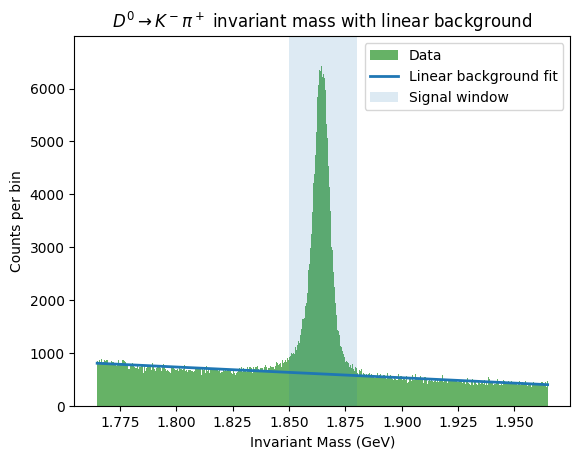

N_cand (data in window): 377758
N_bgd  (linear pred.):   90072.61508547391
N_sig  (subtracted):    287685.3849145261
Purity: 0.7615600064446711


In [4]:
#filter events where k_q and pi_q are opposite in sign
df = df[(df.k_q * df.pi_q) < 0].copy()
df = df[(df.pi_q * df.pis_q) > 0].copy() # this is to make sure we are not modifying the original dataframe and creating a new one with the filtered data]
# ----------------------------
# Invariant mass
# ----------------------------
mass_squared = (
    (df["k_E"] + df["pi_E"])**2
    - (df["k_px"] + df["pi_px"])**2
    - (df["k_py"] + df["pi_py"])**2
    - (df["k_pz"] + df["pi_pz"])**2
)

df["invariant_mass"] = np.sqrt(np.clip(mass_squared, 0, None))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2

# ----------------------------
# Settings
# ----------------------------
signal_low, signal_high = 1.85,1.88
bins = 1000 #one binning used everywhere
def linear_fit(x, a, b):
    return a * x + b

# ----------------------------
# Make ONE histogram over the full range you want to analyze
# ----------------------------
y_all, edges = np.histogram(df["invariant_mass"], bins=bins)
x_all = 0.5 * (edges[1:] + edges[:-1])
bin_width = edges[1] - edges[0]

# ----------------------------
# Sideband mask (exclude signal window)
# Use the BINS for fitting, not the raw events
# ----------------------------
sideband_mask = (x_all < signal_low) | (x_all > signal_high)

x_fit = x_all[sideband_mask]
y_fit = y_all[sideband_mask]

# Poisson uncertainties (avoid zero)
sigma = np.sqrt(np.maximum(y_fit, 1.0))

# ----------------------------
# Weighted linear fit (Poisson)
# ----------------------------
popt, pcov = curve_fit(
    linear_fit,
    x_fit,
    y_fit,
    sigma=sigma,
    absolute_sigma=True
)

# Model on fit bins for chi2
y_model_fit = linear_fit(x_fit, *popt)

chi_2 = np.sum(((y_fit - y_model_fit) / sigma) ** 2)
n_dof = len(x_fit) - len(popt)
red_chi2 = chi_2 / n_dof

chi2_cdf = chi2.cdf(chi_2, n_dof)        # P(Chi2 <= observed)
p_value  = 1.0 - chi2_cdf               # P(Chi2 >= observed)  <-- usual fit p-value

print("Reduced chi²:", red_chi2)
print(f"chi2.cdf = {chi2_cdf:.6f}")
print(f"p-value  = {p_value:.3e}")

print("Fit parameters: a =", popt[0], "b =", popt[1])
print("Reduced chi²:", red_chi2)
print(f"p-value = {p_value:.3e}")

# ----------------------------
# Plot: full histogram + linear background fit + signal window
# ----------------------------
plt.figure()
plt.hist(df["invariant_mass"], bins=bins, color="green", alpha=0.6, label="Data")

x_smooth = np.linspace(x_all.min(), x_all.max(), 2000)
plt.plot(x_smooth, linear_fit(x_smooth, *popt), linewidth=2, label="Linear background fit")

plt.axvspan(signal_low, signal_high, alpha=0.15, label="Signal window")

plt.xlabel("Invariant Mass (GeV)")
plt.ylabel("Counts per bin")
plt.title(r"$D^0 \rightarrow K^- \pi^+$ invariant mass with linear background")
plt.legend()
plt.savefig("invariant_mass_fit.png", dpi=300)
plt.show()

# ----------------------------
# Background prediction in the signal window (CONSISTENT binning)
# ----------------------------
signal_bin_mask = (x_all >= signal_low) & (x_all <= signal_high)

N_cand = y_all[signal_bin_mask].sum()  # candidates = histogram counts in window
N_bgd = linear_fit(x_all[signal_bin_mask], *popt).sum()  # predicted bkg counts in window (sum per-bin)

N_sig = N_cand - N_bgd
purity = 1.0 - (N_bgd / N_cand)

print("N_cand (data in window):", N_cand)
print("N_bgd  (linear pred.):  ", N_bgd)
print("N_sig  (subtracted):   ", N_sig)
print("Purity:", purity)

In [5]:



# ----- Construct D0 3-momentum (K + pi) -----
px_D0 = df["k_px"] + df["pi_px"]
py_D0 = df["k_py"] + df["pi_py"]
pz_D0 = df["k_pz"] + df["pi_pz"]

df["p_D0"] = np.sqrt(px_D0**2 + py_D0**2 + pz_D0**2)

# ----- Background region: everything outside signal window -----
bg_mask = (df["invariant_mass"] < signal_low) | (df["invariant_mass"] > signal_high)

bg_df = df[bg_mask]

# ----- Average background momentum -----
N_bg = len(bg_df)
p_mean = bg_df["p_D0"].mean()
p_std = bg_df["p_D0"].std(ddof=1)
p_err = p_std / np.sqrt(N_bg)  # statistical uncertainty

print("N_background =", N_bg)
print(f"<p_D0>_background = {p_mean:.6f} ± {p_err:.6f} GeV")
print(f"Std deviation = {p_std:.6f} GeV")

N_background = 514986
<p_D0>_background = 1.419020 ± 0.001014 GeV
Std deviation = 0.727823 GeV


In [6]:



# --- 1) per-event D0 candidate momentum magnitude p = |pK + ppi| ---
px = df["k_px"] + df["pi_px"]
py = df["k_py"] + df["pi_py"]
pz = df["k_pz"] + df["pi_pz"]
df["p_D0"] = np.sqrt(px**2 + py**2 + pz**2)

# --- 2) define candidate and background samples by invariant mass window ---
cand_mask = (df["invariant_mass"] >= signal_low) & (df["invariant_mass"] <= signal_high)
bkg_mask  = ~cand_mask   # everything outside the signal window

p_cand = df.loc[cand_mask, "p_D0"].to_numpy()
p_bkg  = df.loc[bkg_mask,  "p_D0"].to_numpy()

# means
p_cand_mean = p_cand.mean()
p_bkg_mean  = p_bkg.mean()

# standard errors on the means (variance / N)^0.5
p_cand_sem = p_cand.std(ddof=1) / np.sqrt(len(p_cand))
p_bkg_sem  = p_bkg.std(ddof=1)  / np.sqrt(len(p_bkg))

# --- 3) purity alpha (you should already have it from your background fit) ---
# If you already computed purity earlier, set it here:
alpha = purity   # <-- use your previously computed purity value (float in [0,1])

sigma_alpha = None  # set to a float if you have it

p_sig_mean = (p_cand_mean - (1 - alpha) * p_bkg_mean) / alpha

# --- 5) uncertainty propagation (recommended) ---
# ignoring sigma_alpha:
p_sig_sem = np.sqrt((p_cand_sem/alpha)**2 + (((1-alpha)*p_bkg_sem)/alpha)**2)

# include sigma_alpha if you have it:
if sigma_alpha is not None:
    dp_dalpha = (p_bkg_mean - p_cand_mean) / (alpha**2)
    p_sig_sem = np.sqrt(p_sig_sem**2 + (dp_dalpha * sigma_alpha)**2)

print("N_cand =", len(p_cand), " N_bkg =", len(p_bkg))
print(f"<p_cand> = {p_cand_mean:.6f} ± {p_cand_sem:.6f} GeV")
print(f"<p_bkg>  = {p_bkg_mean:.6f} ± {p_bkg_sem:.6f} GeV")
print(f"alpha    = {alpha:.6f}" + ("" if sigma_alpha is None else f" ± {sigma_alpha:.6f}"))
print(f"<p_D0> (signal-corrected) = {p_sig_mean:.6f} ± {p_sig_sem:.6f} GeV")

N_cand = 377760  N_bkg = 514986
<p_cand> = 1.702168 ± 0.001435 GeV
<p_bkg>  = 1.419020 ± 0.001014 GeV
alpha    = 0.761560
<p_D0> (signal-corrected) = 1.790820 ± 0.001911 GeV


### Exercise 2.2.2 Reconstruction of D*+ decay

In [7]:
p_D0 = np.sqrt(px_D0**2 + py_D0**2 + pz_D0**2)

# --- slow pion momentum (full 3-momentum if available) ---
# If you only have px, py use the first definition.
# If you also have pz, use the second one instead.

# transverse only:
pis_px = df["pis_px"]
pis_py = df["pis_py"]
pis_pz = df["pis_pz"] if "pis_pz" in df.columns else None

abs_pis_p = np.sqrt(pis_px**2 + pis_py**2 + pis_pz**2)

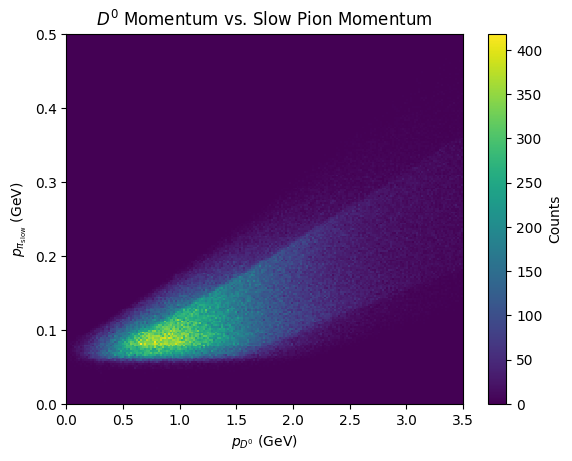

In [8]:


# --- 2D color histogram ---
plt.figure()
plt.hist2d(p_D0, abs_pis_p, bins=200, range=[[0,3.5], [0,0.5]])
plt.xlabel(r"$p_{D^0}$ (GeV)")
plt.ylabel(r"$p_{\pi_{\mathrm{slow}}}$ (GeV)")
plt.title(r"$D^0$ Momentum vs. Slow Pion Momentum")
plt.colorbar(label="Counts")
plt.savefig("momentum_correlation.png", dpi=300)
plt.show()

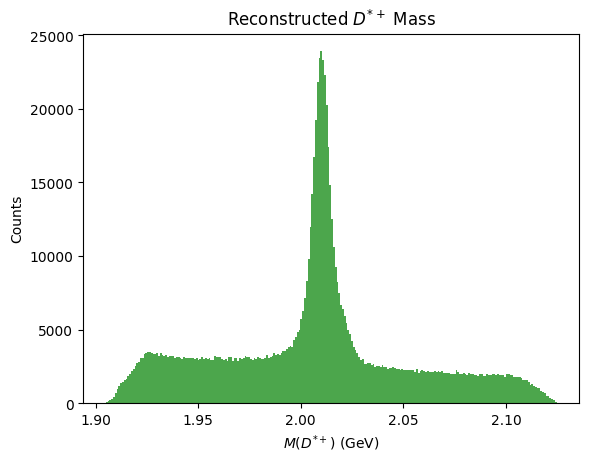

C:\Users\syedm\AppData\Local\Temp\ipykernel_15092\741408633.py:64: RuntimeWarning: invalid value encountered in log
  return a * np.log(x + b) + c
C:\Users\syedm\AppData\Local\Temp\ipykernel_15092\741408633.py:67: RuntimeWarning: invalid value encountered in sqrt
  return a * np.sqrt(x + b) + c


Reduced chi²: 74.28571128447427
p-value = 0.000e+00
Reduced chi² (log fit): 2.0251688662723435
p-value (log fit) = 0.000e+00


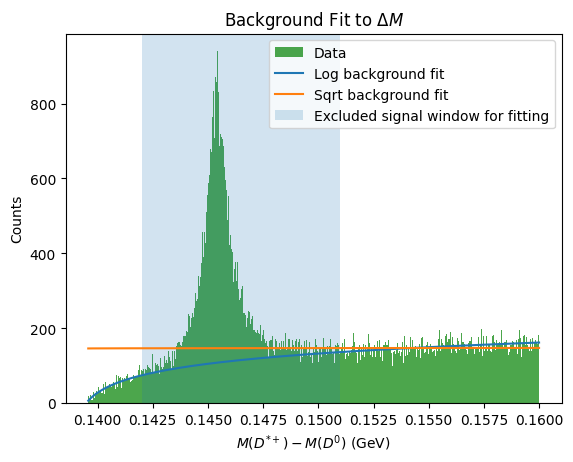

Estimated purity from log fit in signal window: 0.825
Estimated purity from sqrt fit in signal window: 0.763
True signal yield in signal window: 174973.81
parameter_0 = 45.882219 ± 0.422558
parameter_1 = -0.138863 ± 0.000027
parameter_2 = 338.755948 ± 1.785776


In [12]:
def inv_mass(E, px, py, pz):
    """Invariant mass from 4-vector components (natural units c=1)."""
    m2 = E**2 - (px**2 + py**2 + pz**2)
    # protect against tiny negative due to floating point
    return np.sqrt(np.maximum(m2, 0.0))

# -----------------------------
# Build 4-vectors
# Assumes df has columns:
# k_px,k_py,k_pz,k_E
# pi_px,pi_py,pi_pz,pi_E           (the pion from D0)
# pis_px,pis_py,pis_pz,pis_E       (the slow pion from D*+)
# -----------------------------

# D0 = K + pi
E_D0  = df["k_E"]  + df["pi_E"]
px_D0 = df["k_px"] + df["pi_px"]
py_D0 = df["k_py"] + df["pi_py"]
pz_D0 = df["k_pz"] + df["pi_pz"]
M_D0  = inv_mass(E_D0, px_D0, py_D0, pz_D0)

# D*+ = D0 + pi_slow = K + pi + pi_slow
E_Dst  = E_D0  + df["pis_E"]
px_Dst = px_D0 + df["pis_px"]
py_Dst = py_D0 + df["pis_py"]
pz_Dst = pz_D0 + df["pis_pz"]
M_Dstar  = inv_mass(E_Dst, px_Dst, py_Dst, pz_Dst)

# Mass difference
Mdiff = M_Dstar - M_D0
df["Mdiff"] = Mdiff
df["M_D0"] = M_D0

# -----------------------------
# Plot histograms
# -----------------------------

# 1) Histogram of M(D*+)
plt.figure()
plt.hist(M_Dstar, bins=250, color = "green", alpha=0.7)
plt.xlabel(r"$M(D^{*+})$ (GeV)")
plt.ylabel("Counts")
plt.title(r"Reconstructed $D^{*+}$ Mass")
plt.savefig("D+excited_mass.png", dpi=300)
plt.show()

# --- Histogram ---
bins = 5000
counts, edges = np.histogram(Mdiff, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

# --- Exclude signal window ---
lower_bound = 0.142
upper_bound = 0.151
lower_bound_purity = 0.1448
upper_bound_purity = 0.1462
background_mask = (centers < lower_bound) | (centers > upper_bound)

x_fit = centers[background_mask]
y_fit = counts[background_mask]
sigma = np.sqrt(np.maximum(y_fit, 1.0))

def log_fit(x, a, b, c):
    return a * np.log(x + b) + c

def sqrt_fit(x, a, b, c):
    return a * np.sqrt(x + b) + c

b0 = x_fit.min() - 1e-4
p0 = (10.0, b0, np.median(y_fit))

popt_log, pcov_log = curve_fit(
    log_fit, x_fit, y_fit, p0=p0,
    sigma=sigma, absolute_sigma=True,
    bounds=([-np.inf, -np.inf, -np.inf],
            [np.inf, x_fit.min() - 1e-6, np.inf])
)

popt_sqrt, pcov_sqrt = curve_fit(
    sqrt_fit, x_fit, y_fit, p0=p0,
    sigma=sigma, absolute_sigma=True,
    bounds=([-np.inf, -np.inf, -np.inf],
            [np.inf, x_fit.min() - 1e-6, np.inf])
)

x_smooth = np.linspace(centers.min(), centers.max(), 2000)
#the value of reduced chi squared and p-value for the fits can be computed similarly to the previous example, using the fitted model values and the data in the background region.
chi_2 = np.sum(((y_fit - sqrt_fit(x_fit, *popt_sqrt)) / sigma) ** 2)
n_dof = len(x_fit) - len(popt_sqrt)
red_chi2 = chi_2 / n_dof

chi2_cdf = chi2.cdf(chi_2, n_dof)        # P(Chi2 <= observed)
p_value  = 1.0 - chi2_cdf               # P(Chi2 >= observed)  <-- usual fit p-value
print("Reduced chi²:", red_chi2)
print(f"p-value = {p_value:.3e}")
#chi squared and p value for log fit
chi_2_log = np.sum(((y_fit - log_fit(x_fit, *popt_log)) / sigma) ** 2)
n_dof_log = len(x_fit) - len(popt_log)
red_chi2_log = chi_2_log / n_dof_log
chi2_cdf_log = chi2.cdf(chi_2_log, n_dof_log)        # P(Chi2 <= observed)
p_value_log  = 1.0 - chi2_cdf_log               # P(Chi2 >= observed)  <-- usual fit p-value
print("Reduced chi² (log fit):", red_chi2_log)
print(f"p-value (log fit) = {p_value_log:.3e}")

plt.figure()
plt.hist(Mdiff, bins=bins, alpha=0.7, label="Data", color="green")
plt.plot(x_smooth, log_fit(x_smooth, *popt_log), label="Log background fit")
plt.plot(x_smooth, sqrt_fit(x_smooth, *popt_sqrt), label="Sqrt background fit")
plt.axvspan(lower_bound, upper_bound, alpha=0.2, label="Excluded signal window for fitting")
plt.xlabel(r"$M(D^{*+}) - M(D^{0})$ (GeV)")
plt.ylabel("Counts")
plt.title(r"Background Fit to $\Delta M$")
plt.legend()
plt.savefig("mass_difference_background_fit.png", dpi=300)
plt.show()

#calculate the purity. For this, take all events in signal window, substract the background prediction from the fit, and divide by the total number of events in the signal window. This will give you the fraction of signal events in the window, which is the purity.
signal_mask = (centers >= lower_bound_purity) & (centers <= upper_bound_purity)
N_cand = counts[signal_mask].sum()  # candidates = histogram counts in window
N_bgd = log_fit(centers[signal_mask], *popt_log).sum()
purity = (N_cand - N_bgd) / N_cand if N_cand > 0 else 0
print(f"Estimated purity from log fit in signal window: {purity:.3f}")
true_signal_yield = N_cand - N_bgd
#purity from sqrt fit
N_bgd_sqrt = sqrt_fit(centers[signal_mask], *popt_sqrt).sum()
purity_sqrt = (N_cand - N_bgd_sqrt) / N_cand if N_cand > 0 else 0
print(f"Estimated purity from sqrt fit in signal window: {purity_sqrt:.3f}")

print(f"True signal yield in signal window: {true_signal_yield:.2f}")

#fit parameters and their uncertainties for the log fit
for i in range(len(popt_log)):
    print(f"parameter_{i} = {popt_log[i]:.6f} ± {np.sqrt(pcov_log[i][i]):.6f}")


In [62]:
print(np.nanmin(Mdiff), np.nanmax(Mdiff))

0.1448000032943899 0.14619996541944258


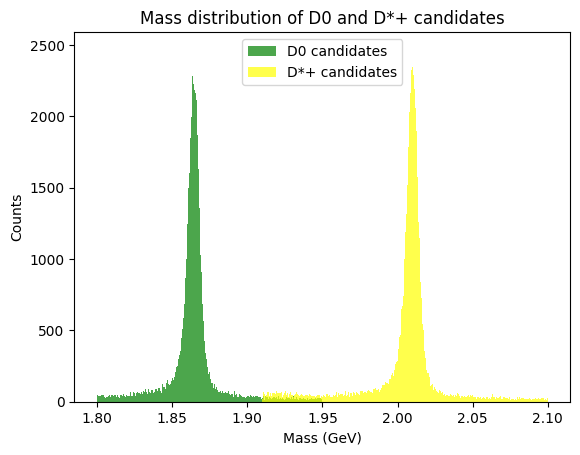

In [60]:
df = df[(df.Mdiff > 0.1448) & (df.Mdiff < 0.1462)].copy() # lower_bound_purity = 0.1448 upper_bound_purity = 0.1462
plt.hist(df["M_D0"], bins=1000, color="green", alpha=0.7, range = (1.8, 1.95))
plt.hist(df["M_Dstar"], bins=1300, color="yellow", alpha=0.7, range = (1.9, 2.1))
plt.xlabel("Mass (GeV)")
plt.ylabel("Counts")
plt.title("Mass distribution of D0 and D*+ candidates")
plt.legend(["D0 candidates", "D*+ candidates"])
plt.savefig("D0_Dstar_mass_distribution.png", dpi=300)
plt.show()

### Exercise 2.2.3

In [65]:
df.Ls_z0 - df.Lt_z0

6          0.019797
14        -0.040241
23         0.030581
28         0.022409
32         0.020934
             ...   
2463937   -0.019580
2463939   -1.794155
2463942   -0.039683
2463978   -0.465287
2463986    0.001463
Length: 212130, dtype: float64

### Asymmmetry Function

D = 0.1287 ± 0.0041
Δm = 0.5364 ± 0.0099  (1/ps)
b = 0.0766 ± 0.0034
chi2/ndf = 2.957, p-value = 5.046e-11


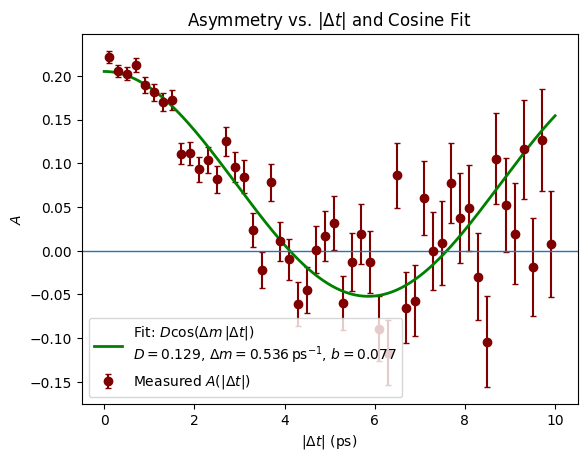

In [72]:


# ----------------------------
# 0) (Optional) apply your "good D* sample" cuts first
#    e.g. on Mdiff, D0 mass, charge consistency, etc.
# ----------------------------
# df = df[...]  # your D* purity selection here

# ----------------------------
# 1) Build z0(D*+) from the three D* decay tracks
# ----------------------------
df = df.copy()
df["z0_Dstar"] = (df["k_z0"] + df["pi_z0"] + df["pis_z0"]) / 3.0

# ----------------------------
# 2) Choose signal lepton: the one with z0 closer to z0(D*)
#    (the other becomes tag)
# ----------------------------
dLs = (df["Ls_z0"] - df["z0_Dstar"]).abs()
dLt = (df["Lt_z0"] - df["z0_Dstar"]).abs()

sig_is_Ls = dLs <= dLt

df["Lsig_q"]  = np.where(sig_is_Ls, df["Ls_q"],  df["Lt_q"])
df["Ltag_q"]  = np.where(sig_is_Ls, df["Lt_q"],  df["Ls_q"])
df["Lsig_z0"] = np.where(sig_is_Ls, df["Ls_z0"], df["Lt_z0"])
df["Ltag_z0"] = np.where(sig_is_Ls, df["Lt_z0"], df["Ls_z0"])

# ----------------------------
# 3) Oscillation classification from lepton charges
#    opposite charge => not-oscillated
#    same charge     => oscillated
# ----------------------------
same_charge = (df["Lsig_q"] * df["Ltag_q"]) > 0
df["is_osc"] = same_charge
df["is_not"] = ~same_charge

# ----------------------------
# 4) Build asymmetry A(|Δt|) in bins
# ----------------------------
# Use |Δt| variable provided in the dataframe (script calls it deltat).
# If your column name differs, change here:
dt = df["deltat"].to_numpy()
dt_abs = np.abs(dt)

# Fit/plot range suggestion from script: |Δt| < 8..12 ps
dt_max = 10.0
mask_dt = np.isfinite(dt_abs) & (dt_abs < dt_max)

dt_abs = dt_abs[mask_dt]
is_osc = df.loc[mask_dt, "is_osc"].to_numpy()
is_not = df.loc[mask_dt, "is_not"].to_numpy()

# Binning
nbins = 50
edges = np.linspace(0.0, dt_max, nbins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

N_osc = np.zeros(nbins, dtype=float)
N_not = np.zeros(nbins, dtype=float)

bin_idx = np.clip(np.digitize(dt_abs, edges) - 1, 0, nbins - 1)

for i in range(nbins):
    sel = bin_idx == i
    N_osc[i] = np.sum(is_osc[sel])
    N_not[i] = np.sum(is_not[sel])

N_tot = N_osc + N_not

# Asymmetry
A = np.full(nbins, np.nan)
A[N_tot > 0] = (N_not[N_tot > 0] - N_osc[N_tot > 0]) / N_tot[N_tot > 0]

# Uncertainty on asymmetry from binomial counting:
# sigma_A = sqrt((1 - A^2) / N_tot)  (valid when N_tot large enough)
sigma_A = np.full(nbins, np.nan)
good = N_tot > 0
sigma_A[good] = np.sqrt(np.maximum(1.0 - A[good]**2, 0.0) / N_tot[good])

# Keep only bins with enough statistics
min_counts = 20
use = good & (N_tot >= min_counts) & np.isfinite(A) & np.isfinite(sigma_A)

x = centers[use]
y = A[use]
sy = sigma_A[use]

# ----------------------------
# 5) Fit cosine: A(|Δt|) = D cos(Δm |Δt|)
#    (Optional offset c0 if you suspect a constant bias)
# ----------------------------
def cos_model(t, D, dm, b):
    return D * np.cos(dm * t) + b

# optional model with offset:
def cos_model_offset(t, D, dm, c0):
    return D * np.cos(dm * t) + c0

# Initial guesses:
p0 = (0.8, 0.5, 0.0)  # D ~ O(1), dm ~ 0.5 1/ps is a reasonable start, b ~ 0

popt, pcov = curve_fit(
    cos_model, x, y, p0=p0,
    sigma=sy, absolute_sigma=True
)

D_fit, dm_fit, b_fit = popt
D_err, dm_err, b_err = np.sqrt(np.diag(pcov))

# Chi2 / ndf and p-value
y_fit = cos_model(x, *popt)
chi2_val = np.sum(((y - y_fit) / sy)**2)
ndf = len(x) - len(popt)
red_chi2 = chi2_val / ndf if ndf > 0 else np.nan
pval = 1.0 - chi2.cdf(chi2_val, ndf) if ndf > 0 else np.nan

print(f"D = {D_fit:.4f} ± {D_err:.4f}")
print(f"Δm = {dm_fit:.4f} ± {dm_err:.4f}  (1/ps)")
print(f"b = {b_fit:.4f} ± {b_err:.4f}")
print(f"chi2/ndf = {red_chi2:.3f}, p-value = {pval:.3e}")

# ----------------------------
# 6) Plot asymmetry + fit
# ----------------------------
t_smooth = np.linspace(0.0, dt_max, 2000)

plt.figure()
plt.errorbar(x, y, yerr=sy, fmt='o', capsize=2, label=r"Measured $A(|\Delta t|)$", color = "maroon")
plt.plot(t_smooth, cos_model(t_smooth, *popt), linewidth=2,
         label=rf"Fit: $D\cos(\Delta m\,|\Delta t|)$" + "\n"
               + rf"$D={D_fit:.3f}$, $\Delta m={dm_fit:.3f}\,\mathrm{{ps^{{-1}}}}$, $b={b_fit:.3f}$", color = "green")

plt.axhline(0.0, linewidth=1)
plt.xlabel(r"$|\Delta t|$ (ps)")
plt.ylabel(r"$A$")
plt.title(r"Asymmetry vs. $|\Delta t|$ and Cosine Fit")
plt.legend()
plt.savefig("asymmetry_fit.png", dpi=300)
plt.show()